## Descriptive analysis & preprocessing

In [1]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats
import statistics
import re
import datetime

In [2]:
#load files
path = 'data/'
data_cons = pd.read_csv(path + 'data-cons.csv', sep = ";")
data_temp = pd.read_csv(path + 'data-sensor.csv', sep = ";")
data_hvac = pd.read_csv(path + 'data-hvac.csv', sep = ";")
data_weather = pd.read_csv(path + 'MU62_dm.txt', sep=";")
data_co2 = pd.read_csv(path + 'data-CO2.csv', sep = ";")
data_presence = pd.read_csv(path + 'data-presence.csv', sep = ",")
relations_sensor = pd.read_csv(path + "relations-sensor.csv", sep = ";") 
relations_hvac = pd.read_csv(path + "relations-hvac.csv", sep = ";")   
relations_presence = pd.read_csv(path + 'relations-presence.csv', sep=';')
relations_co2 = pd.read_csv(path + 'relations-CO2.csv', sep=';')

### Consumption (data_cons)

Consumption data has four features:
- **ID**: unique identifier for each observation.
- **IDdevice**: idenfifier with 3 possible values, each referencing a block of the building (A, B or C):  335546928 (A), 335546926 (B), 335546927 (C).
- **Date**: timestamp with format %Y-%m-%d %H:%M:%S.
- **V22**: aggregated consumption in kWh.

In [3]:
data_cons.head(3)

,ID,IDdevice,Date,V22
0,4872244,335546926,2021-12-31 23:56:08.958+01,85105.304688
1,4872242,335546928,2021-12-31 23:56:08.958+01,188499.625000
2,4872241,335546927,2021-12-31 23:56:04.953+01,129472.710938


In [4]:
data_cons.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154833 entries, 0 to 154832
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   ID        154833 non-null  int64  
 1   IDdevice  154833 non-null  int64  
 2   Date      154833 non-null  object 
 3   V22       154833 non-null  float64
dtypes: float64(1), int64(2), object(1)
memory usage: 4.7+ MB


Create a function to separate samples by building block, resampling so we have uniform timesteps of 60 minutes, and adding a column that accounts for the total consumption from the start to the end of the data gathering and for the consumption from a time $t$ to $t+1$:

In [5]:
def create_data_cons(edificio, datos, interval):
    data = datos
    ids = np.NaN
    # data_cons['IDdispositivo'].unique() to see the id's
    if edificio == 'A': ids = 335546928
    if edificio == 'B': ids = 335546926
    if edificio == 'C': ids = 335546927
    #Select one block
    mask = data['IDdevice'].isin([ids])
    df = data.loc[mask]
    df = df.iloc[::-1]
    #Create a column that is the conssumpltion difference between t and t-1
    df.insert(2, "dif_cons", df['V22'].diff(), True)
    df = df.set_index('Date')
    df.index = pd.to_datetime(df.index, utc = True)
    #60 min resample
    df = df.resample(interval)['dif_cons'].sum().to_frame()
    #Create a column that is the accumulated consumption until the current time
    df.insert(1, "cons_total", df['dif_cons'].cumsum(), True)
    #Set the date limit until the date that we have weather data
    mask = (df.index >= '2021-01-01 00:00:00') & (df.index <= '2021-12-18 00:00:01')
    df = df.loc[mask]
    #Save into differente files
    df.to_csv(path + 'cons'+ edificio + '-' + interval + '.csv', sep=";")

In [6]:
res_time = '60T'
blocks = ['A','B','C']

In [7]:
#Call the function
for block in blocks: create_data_cons(block, data_cons, res_time)

In [8]:
#Load data into a dictionary
cons = dict()
for key in blocks:
    cons[key] = pd.read_csv(path + 'cons' + key +'-' + res_time + '.csv', sep=";")

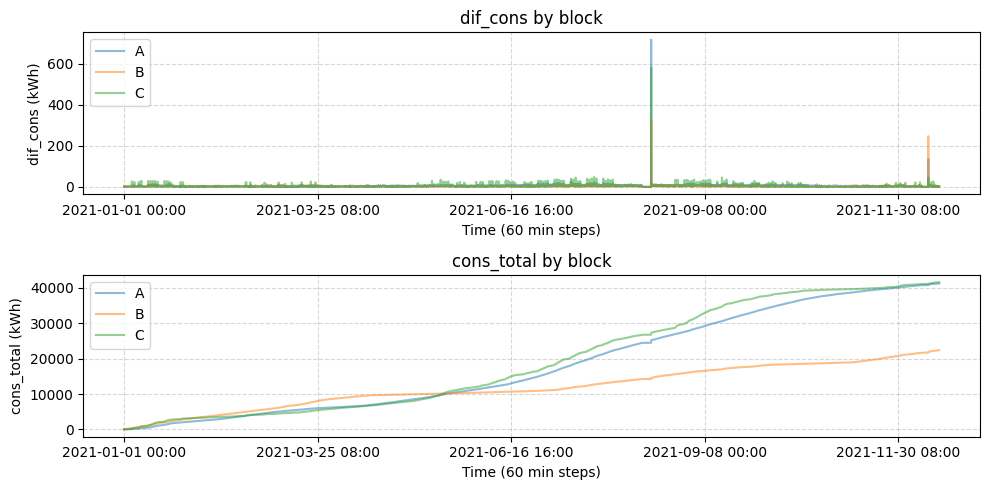

In [9]:
#Plot accumulated consumtion and consumption differences
fig, axs = plt.subplots(figsize=(10,5), nrows = 2, ncols =1, sharex =False)
for count, feature in enumerate(['dif_cons', 'cons_total']):
    axs[count].plot(pd.to_datetime(cons['A']['Date']).dt.strftime("%Y-%m-%d %H:%M"), cons['A'][feature], label="A", alpha=0.5)
    axs[count].plot(pd.to_datetime(cons['B']['Date']).dt.strftime("%Y-%m-%d %H:%M"), cons['B'][feature], label="B", alpha=0.5)
    axs[count].plot(pd.to_datetime(cons['C']['Date']).dt.strftime("%Y-%m-%d %H:%M"), cons['C'][feature], label="C", alpha=0.5)
    axs[count].set_xticks(np.arange(0, len(cons['A']), 2000))
    axs[count].grid(linestyle = "--", alpha=0.5)
    axs[count].legend(loc="upper left")
    axs[count].set_ylabel(feature + ' (kWh)')
    axs[count].set_xlabel('Time (60 min steps)')
    axs[count].set_title(feature + ' by block')
fig.tight_layout()
#plt.savefig("Consumo1_date.svg")
plt.show()

Here we see two irregularities that affect the three blocks. These two events are a set of 0's lasting for over 300 observations followed by a huge peak. Based on this, we decide to remove observations larger that 25 or equal to 0. Smoothing or interpolation is not useful in this situation because with so many zeros that interval ends up being constant which is not what we expect from a consumption standpoint.

Once we do that, there are no extreme peaks like before, but it seems like there is a lot of noise. To solve that we do a smoothing with *dif_cons* (punctual consumption). The function to split consumption by block with all these steps is the following:

In [10]:
def create_data_cons(edificio, datos, interval):
    data = datos
    ids = np.NaN
    # data_cons['IDdevice'].unique() to see the id's
    if edificio == 'A': ids = 335546928
    if edificio == 'B': ids = 335546926
    if edificio == 'C': ids = 335546927
    #Select one block
    mask = data['IDdevice'].isin([ids])
    df = data.loc[mask]
    df = df.iloc[::-1]
    #Create a column that is the conssumpltion difference between t and t-1
    df.insert(2, "dif_cons", df['V22'].diff(), True)
    df = df.set_index('Date')
    df.index = pd.to_datetime(df.index, utc = True)
    #60 min resample
    df = df.resample(interval)['dif_cons'].sum().to_frame()
    #Create a column that is the accumulated consumption until the current time
    df.insert(1, "cons_total", df['dif_cons'].cumsum(), True)
    #Remove peaks and zeros
    df = df.where(df['dif_cons']>0).dropna()
    df = df.where(df['dif_cons']<25).dropna()
    #Smoothing (in a new column, keeping both the real and smoothed)
    df['dif_cons_smooth'] = df['dif_cons'].ewm(span = 4).mean()
    df = df.rename(columns={"dif_cons": "dif_cons_real"})
    df = df.round({'dif_cons_real': 2, 'dif_cons_smooth': 2, 'cons_total': 2})
    #Set the date limit until the date that we have weather data
    mask = (df.index >= '2021-01-01 00:00:00') & (df.index <= '2021-12-18 00:00:01')
    df = df.loc[mask]
    #Save into differente files
    df.to_csv(path + 'cons'+ edificio + '-' + interval + '.csv', sep=";")

In [11]:
res_time = '60T'
blocks = ['A','B','C']

In [12]:
#Call the function
for block in blocks: create_data_cons(block, data_cons, res_time)

In [13]:
#Load data into a dictionary
cons = dict()
for key in blocks:
    cons[key] = pd.read_csv(path + 'cons' + key +'-' + res_time + '.csv', sep=";")

In [14]:
#See the new DataFrame
cons['A'].head(3)

,Date,dif_cons_real,cons_total,dif_cons_smooth
0,2021-01-01 00:00:00+00:00,1.34,2.44,1.25
1,2021-01-01 01:00:00+00:00,1.31,3.75,1.28
2,2021-01-01 02:00:00+00:00,1.30,5.05,1.29


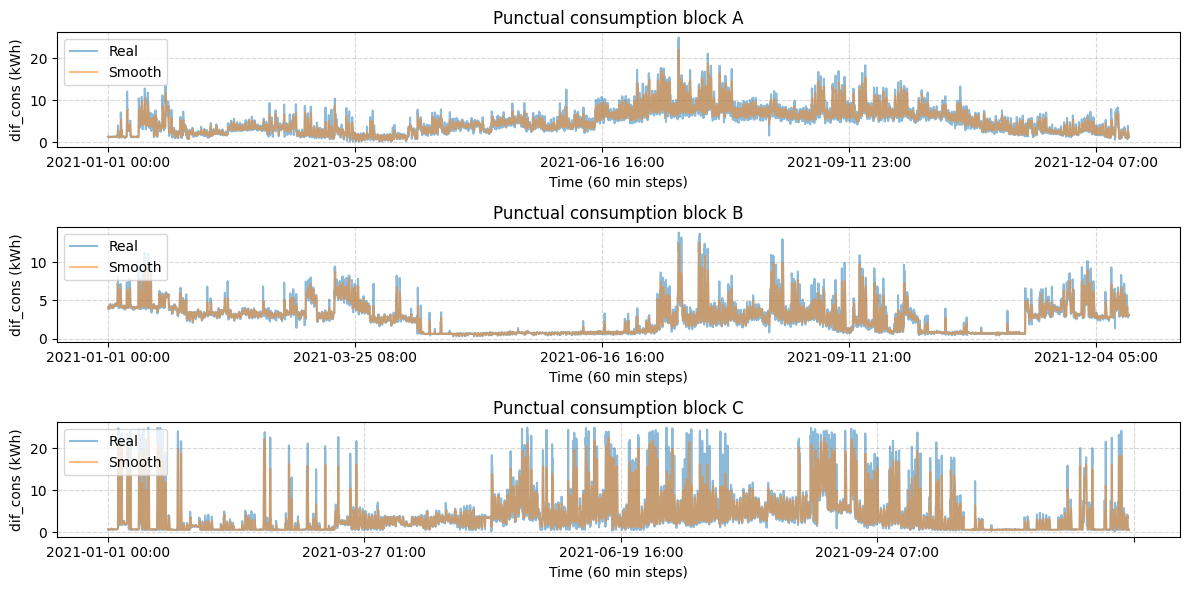

In [15]:
#Plot dif_cons (real & smooth) for each block
fig, axs = plt.subplots(figsize=(12,6), nrows = 3, ncols =1, sharex =False)
for count, block in enumerate(['A','B','C']):
    axs[count].plot(pd.to_datetime(cons[block]['Date']).dt.strftime("%Y-%m-%d %H:%M"), cons[block]['dif_cons_real'], label="Real", alpha=0.5)
    axs[count].plot(pd.to_datetime(cons[block]['Date']).dt.strftime("%Y-%m-%d %H:%M"), cons[block]['dif_cons_smooth'], label="Smooth", alpha=0.5)
    axs[count].set_xticks(np.arange(0, len(cons['A']), 2000))
    axs[count].grid(linestyle = "--", alpha=0.5)
    axs[count].legend(loc="upper left")
    axs[count].set_ylabel("dif_cons")
    axs[count].set_ylabel('dif_cons (kWh)')
    axs[count].set_xlabel('Time (60 min steps)')
    axs[count].set_title("Punctual consumption block " + block)
fig.tight_layout()
#plt.savefig("Consumo2_date.svg")
plt.show()

Now there are no extreme peaks and we can see a behaviour more in line with what we could expect

Lastly, we plot correlations for accumulated and punctual consumption between blocks

/tmp/ipykernel_17157/2049411250.py:7: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_cons_total=df2.corr()
/tmp/ipykernel_17157/2049411250.py:8: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_dif=df4.corr()


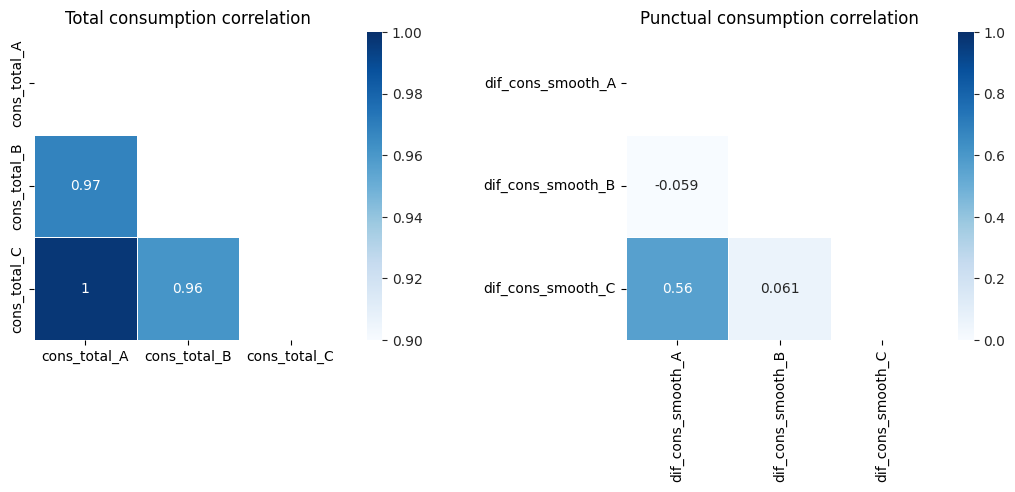

In [16]:
df1 = pd.merge(cons['A'][['Date','cons_total']],cons['B'][['Date','cons_total']], on = "Date", suffixes=('_A', '_B'))
df2 = pd.merge(df1[['Date','cons_total_A', 'cons_total_B']],cons['C'][['Date','cons_total']], on = "Date").rename(columns={"cons_total": "cons_total_C"})
df2.rename(columns={"cons_total": "cons_total_C"})
df3 = pd.merge(cons['A'][['Date','dif_cons_smooth']],cons['B'][['Date','dif_cons_smooth']], on = "Date", suffixes=('_A', '_B'))
df4 = pd.merge(df3[['Date','dif_cons_smooth_A', 'dif_cons_smooth_B']],cons['C'][['Date','dif_cons_smooth']], on = "Date").rename(columns={"dif_cons_smooth": "dif_cons_smooth_C"})
df4.rename(columns={"dif_cons_smooth": "dif_cons_smooth_C"})
corr_cons_total=df2.corr()
corr_dif=df4.corr()
mask1 = np.zeros_like(corr_cons_total)
mask1[np.triu_indices_from(mask1)] = True
mask2 = np.zeros_like(corr_cons_total)
mask2[np.triu_indices_from(mask2)] = True

fig, axs = plt.subplots(figsize = (14,4), nrows = 1, ncols =2) # width x height
with sns.axes_style("white"):
    axs[0] = sns.heatmap(corr_cons_total, ax=axs[0],
                     xticklabels=corr_cons_total, yticklabels=corr_cons_total,
                     mask=mask1, vmin=0.9, vmax=1, square=True,
                     annot = True, linewidths=.5, cmap="Blues")
    axs[0].set_title('Total consumption correlation')
    axs[1] = sns.heatmap(corr_dif, ax=axs[1],
                 xticklabels=corr_dif, yticklabels=corr_dif,
                 mask=mask2, vmin=0, vmax=1, square=True,
                 annot = True, linewidths=.5, cmap="Blues")
    axs[1].set_title('Punctual consumption correlation')
#plt.savefig("Consumo3.svg")

We see that even though total accumulated consumption is highly correlated that is not the case for punctual consumption. Therefore, in order to predict punctual consumption it would be advisable to develop a model for each block.

### Relations (relations_sensor & relations_hvac)

These files provide information about sensor and hvacs locations, respectively. Each device has an ID related to a room and a block.

In [17]:
relations_sensor.head(3)

,ID,block,room
0,335544455,A,71
1,335544458,A,72
2,335544461,A,73


In [18]:
relations_hvac.head(3)

,ID,block,room
0,335545147,B,1
1,335545149,B,1
2,335545143,B,2


Create a *dict()* so we have lists of devices ids and sensorized/monitored rooms. Those lists will be needed to process other datasets.

In [19]:
blocks = ['A','B','C']
ids_sensor = dict()
ids_hvac = dict()
rooms_sensor = dict()
rooms_hvac = dict()
for key in blocks:
    ids_sensor[key] = relations_sensor['ID'].where(relations_sensor['block']== key).dropna().unique().astype(int).tolist()
    ids_hvac[key] = relations_hvac['ID'].where(relations_hvac['block']== key).dropna().unique().astype(int).tolist()
    rooms_sensor[key] = relations_sensor['room'].where(relations_sensor['block']== key).dropna().unique().tolist()
    rooms_hvac[key] = relations_hvac['room'].where(relations_hvac['block']== key).dropna().unique().tolist()

### Temperature (data_temp)

Temperature data only has three features:
- **IDdevice**: identifier of the sensor and related to a room by the previous step.
- **Date**: timestamp with format %Y-%m-%d %H:%M:%S.
- **V2**: temperature in $^\circ$C.

In [20]:
data_temp.head(3)

,IDdevice,Date,V2
0,335544547,2021-12-31 23:55:19.635+01,22.659363
1,335544544,2021-12-31 23:55:19.635+01,5.000000
2,335544543,2021-12-31 23:55:19.635+01,34.481567


In [21]:
data_temp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9857796 entries, 0 to 9857795
Data columns (total 3 columns):
 #   Column    Dtype  
---  ------    -----  
 0   IDdevice  int64  
 1   Date      object 
 2   V2        float64
dtypes: float64(1), int64(1), object(1)
memory usage: 225.6+ MB


In [22]:
data_temp.describe()

,IDdevice,V2
count,9.857796e+06,9.857796e+06
mean,3.355447e+08,NaN
std,1.959102e+02,NaN
min,3.355445e+08,-1.069065e+306
25%,3.355446e+08,5.000000e+00
50%,3.355447e+08,2.647070e+01
75%,3.355449e+08,3.555093e+01
max,3.355451e+08,5.657122e+307


This datasets presents several errors, with extreme values that do not make sense. This values are removed and replaced with a *forward fill* by the last valid value.

Like in consumption a resample is necessary, this time taking the mean temperature.

In [23]:
def create_data_temp(ids_sensor, edificio, datos, interval):
    ids = ids_sensor
    data = datos
    #Take data corresponding to one of the blocks
    mask = data['IDdevice'].isin(ids)
    df = data.loc[mask]
    df = df.sort_values(by=['IDdevice', 'Date'], ascending=True)
    #Put extreme values as NaN and rewrite them with the previous valid value
    mask = (data['V2']<15) | (data['V2']>40)
    data.loc[mask, 'V2'] = np.nan
    df['V2'] = df['V2'].fillna(method="ffill")
    #Set Date(date) as index
    df = df.sort_values(by=['Date'], ascending=False)
    df = df.set_index('Date')
    df.index = pd.to_datetime(df.index, utc = True)
    #V2 resample
    df = df.groupby('IDdevice').resample(interval)['V2'].mean().to_frame()
    df['V2'] = df['V2'].fillna(method="ffill").round(2)
    df = df.reset_index()
    #Group by date
    df = df[['Date', 'V2']].groupby('Date').mean()
    #Set the date limit until the date that we have weather data
    mask = (df.index >= '2021-01-01 00:00:01') & (df.index <= '2021-12-18 00:00:01')
    df = df.loc[mask]
    df.to_csv(path + 'temp-sensor' + edificio + '-' + interval + '.csv', sep=";")

In [24]:
#Call function
for block in blocks: create_data_temp(ids_sensor[block],block, data_temp, res_time)

In [25]:
#Load data into a dictionary
temp = dict()
for key in blocks:
    temp[key] = pd.read_csv(path + 'temp-sensor' + key +'-' + res_time + '.csv', sep=";")

In [26]:
#Example of DataFrame saved in the dictionary
temp['A'].head(3)

,Date,V2
0,2021-01-01 01:00:00+00:00,22.686829
1,2021-01-01 02:00:00+00:00,22.642439
2,2021-01-01 03:00:00+00:00,22.558780


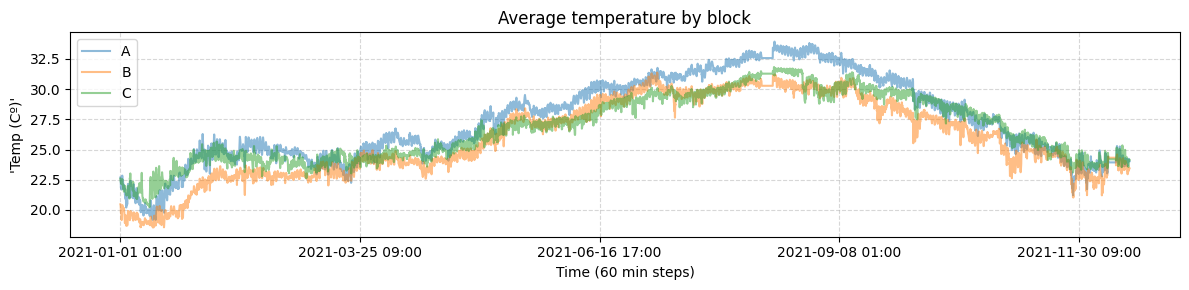

In [27]:
#Plot mean temperature by block
fig, axs = plt.subplots(figsize=(12,3), nrows = 1, ncols =1, sharex =False)
for count, block in enumerate(['A','B','C']):
    axs.plot(pd.to_datetime(temp[block]['Date']).dt.strftime("%Y-%m-%d %H:%M"),temp[block]['V2'], label=block, alpha=0.5)
    axs.set_xticks(np.arange(0, len(temp['A']), 2000))
    axs.grid(linestyle = "--", alpha=0.5)
    axs.legend(loc="upper left")
    axs.set_ylabel("'Temp (Cº)'")
    axs.set_xlabel("Time (60 min steps)")
    axs.set_title("Average temperature by block")
fig.tight_layout()
#plt.savefig("Temp1_date.svg")
plt.show()

/tmp/ipykernel_17157/471038378.py:5: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr=df2.corr()


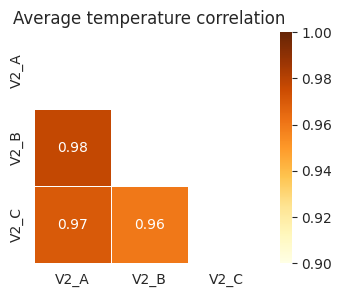

In [28]:
#Plot correlation
df1 = pd.merge(temp['A'][['Date','V2']],temp['B'][['Date','V2']], on = "Date", suffixes=('_A', '_B'))
df2 = pd.merge(df1[['Date','V2_A', 'V2_B']],temp['C'][['Date','V2']], on = "Date").rename(columns={"V2": "V2_C"})
df2.rename(columns={"V2": "V2_C"})
corr=df2.corr()
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True
with sns.axes_style("white"):
    f, ax = plt.subplots(figsize=(4, 3))
    ax = sns.heatmap(corr, 
                     xticklabels=corr, yticklabels=corr,
                     mask=mask, vmin=0.9, vmax=1, square=True,
                     annot = True, linewidths=.5, cmap="YlOrBr")
    ax.set_title('Average temperature correlation')
#plt.savefig("Temp2.svg")

We observe that temperature correlation is almost 1 accross the three blocks, therefore, developing only one temperature forecast model makes sense and at first sight, it would not be necessary to create a model for each block.

### HVAC (data_hvac)

This datasets contains the following features:
- **IDdevice**: identifier of the HVAC device
- **Date**: timestamp with format %Y-%m-%d %H:%M:%S.
- **V4**: state, 0 if OFF, 1 if ON
- **V5**: Operation mode:
    * 0 = not established
    * 1 = heating
    * 2 = cooling
    * 3 = dry
    * 4 = fan
    * *Will be recoded as: 0 = none, 1 = heating, 2 = cooling. (The others will disappear during resampling)*
- V6: fan mode (not used)
- **V12**: setpoint, temperature set by the user
- **V26**: device type (wall/ceiling)

In [29]:
data_hvac.head(3)

,IDdevice,Date,V4,V5,V6,V12,V26
0,335545219,2021-12-31 23:51:40.395+01,0,1,3,29.0,2
1,335545217,2021-12-31 23:51:40.395+01,0,1,3,23.0,2
2,335545215,2021-12-31 23:51:40.395+01,0,1,3,23.0,2


In [30]:
data_hvac.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4339076 entries, 0 to 4339075
Data columns (total 7 columns):
 #   Column    Dtype  
---  ------    -----  
 0   IDdevice  int64  
 1   Date      object 
 2   V4        int64  
 3   V5        int64  
 4   V6        int64  
 5   V12       float64
 6   V26       int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 231.7+ MB


In the following function we: (i) Replace extreme values of V12, like we did with V2 in temperature; (ii) Resample V4 to get the number of turned on HVACs; (iii) Resample V12 to get the mean setpoint temperature; (iv) Resample V5 to get the predominant operation mode; (v) Resample V26 to get a mean with the device type; (vi) Merge those resamples; (vii) Add a feature to split the day in three parts (morning/afternoon/night); (viii) Add a feature to split the year in seasons.

In [31]:
def create_data_hvac(ids_hvac, edificio, datos, interval):
    data = datos
    ids = ids_hvac
    mask = data['IDdevice'].isin(ids)
    df = data.loc[mask]
    #Order by ID and date. Then replace V12 null values with forward fill
    df = df.sort_values(by=['IDdevice', 'Date'], ascending=True)
    mask = (data['V12']<=0) | (data['V12']>60)
    data.loc[mask, 'V12'] = np.nan
    df['V12'] = df['V12'].fillna(method="ffill")
    #Order by date and set index
    df = df.sort_values(by=['Date'], ascending=False)
    df0 = df.set_index('Date')
    df0.index = pd.to_datetime(df0.index, utc = True)
    #V4 resample
    df1 = df0.groupby('IDdevice').resample(interval)['V4'].mean().to_frame()
    df1 = df1.reset_index()
    dfON = df1[['Date', 'V4']].groupby(['Date']).sum().round(0)
    #V12 resample
    df2 = df0.groupby('IDdevice').resample(interval)['V12'].mean().to_frame().reset_index()
    df2['V12'] = df2['V12'].fillna(method="ffill")
    dfSETpoint = df2[['Date', 'V12']].groupby(['Date']).mean().round(2)
    #V5 resample
    df3 = df0.groupby('IDdevice').resample(interval)['V5'].median().to_frame().reset_index()
    df3['V5'] = df3['V5'].fillna(method="ffill")
    dfV5median = df3[['Date', 'V5']].groupby(['Date']).median()
    #V26 resample
    #In block A all the devices are type 2 (ceiling), in B and C we have both
    #En edificio A todos son de tipo 2, en B y C hay de ambos.
    #If V4=0, we set V26 as 0, so we have V26 = 0 (off), = 1 (wall), = 2 (ceiling)
    #The resample is performed with a mean, which will return a value 0 <= x <= 2
    mask = (df0['V4']==0)
    df0.loc[mask, 'V26'] = 0
    df4 = df0.groupby('IDdevice').resample(interval)['V26'].mean().round(1).to_frame().reset_index()
    df4['V26'] = df4['V26'].fillna(method="ffill")
    dfV26median = df4[['Date', 'V26']].groupby(['Date']).mean().round(1)
    #Merge dataframes and create dummies for the HVAC mode (0=off, 1=heating, 2=cooling)
    mixed = dfON.merge(dfSETpoint, left_index=True, right_index=True, how='outer')
    mixed = mixed.merge(dfV5median, left_index=True, right_index=True, how='outer')
    mixed = mixed.merge(dfV26median, left_index=True, right_index=True, how='outer')
    mixed['V5'] = mixed['V5'].astype(int)
    #To fix inconsistencies so when V4=0, mode is 0
    mask = (mixed['V4']==0)
    mixed.loc[mask, 'V5'] = 0
    mixed = pd.concat([mixed, pd.get_dummies(mixed.V5, prefix='V5')], axis=1).drop(columns=['V5'])
    #Add a feature to split the day in three parts (morning/afternoon/night) and put it as dummy
    def Hour_(Hour):
        if Hour in range(6,14): return 1
        if Hour in range(14,22): return 2
        if Hour in [22,23,0,1,2,3,4,5]: return 3
    mixed['Hour'] = mixed.index.hour
    mixed['Hour'] = mixed['Hour'].apply(Hour_).astype(int)
    mixed = pd.concat([mixed, pd.get_dummies(mixed.Hour, prefix='Hour')], axis=1).drop(columns=['Hour'])
    #Add a feature to split the year in seasons (taking the month)
    def season(Mes):
        if Mes in range(1,4): return 1
        if Mes in range(4,7): return 2
        if Mes in range(7,10): return 3
        if Mes in range(10,13): return 4   
    mixed['Season'] = mixed.index.month
    mixed['Season'] = mixed['Season'].apply(season).astype(int)
    mixed = pd.concat([mixed, pd.get_dummies(mixed['Season'], prefix='Season')], axis=1).drop(columns=['Season'])
    #Set the date limit until the date that we have weather data
    mask = (mixed.index >= '2021-01-01 00:00:00') & (mixed.index <= '2021-12-18 00:00:01')
    mixed = mixed.loc[mask]
    mixed.to_csv(path + 'hvac-agg' + edificio + '-' + interval + '.csv', sep=";")

In [32]:
#Call fuction
for block in blocks: create_data_hvac(ids_hvac[block],block, data_hvac, res_time)

In [33]:
#Load hvac data into a dictionary
hvac = dict()
for key in blocks:
    hvac[key] = pd.read_csv(path + 'hvac-agg' + key +'-' + res_time + '.csv', sep=";")

In [34]:
hvac['A'].head(3)

,Date,V4,V12,V26,V5_0,V5_1,V5_2,Hour_1,Hour_2,Hour_3,Season_1,Season_2,Season_3,Season_4
0,2021-01-01 00:00:00+00:00,1.0,14.1,0.0,0,1,0,0,0,1,1,0,0,0
1,2021-01-01 01:00:00+00:00,1.0,14.1,0.0,0,1,0,0,0,1,1,0,0,0
2,2021-01-01 02:00:00+00:00,1.0,14.1,0.0,0,1,0,0,0,1,1,0,0,0


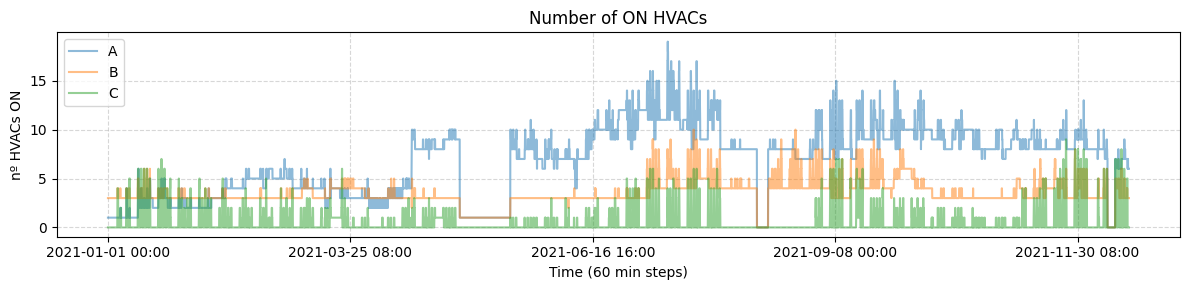

In [35]:
#Plot the number of turned on HVACs
fig, axs = plt.subplots(figsize=(12,3), nrows = 1, ncols =1, sharex =False)
for count, block in enumerate(['A','B','C']):
    axs.plot(pd.to_datetime(hvac[block]['Date']).dt.strftime("%Y-%m-%d %H:%M"), hvac[block]['V4'], label=block, alpha=0.5)
    axs.grid(linestyle = "--", alpha=0.5)
    axs.set_xticks(np.arange(0, len(cons['A']), 2000))
    axs.legend(loc="upper left")
    axs.set_ylabel("nº HVACs ON")
    axs.set_xlabel("Time (60 min steps)")
    axs.set_title("Number of ON HVACs")
fig.tight_layout()
#plt.savefig("HVAC1_date.svg")
plt.show()

### Weather (data_weather)

Weather data has the following features:
- **Fecha**: date, with format %d/%m/%y 
- **Hora**: hour, with format %H:%M:%S
- **tmed, tmax, tmin**: mean, max and min temperature 
- **hrmed, hrmax, hrmin**: relative humidity
- **radmed, radmax**: solar radiation
- **vvmed, vvmax**: wind speed
- **dvmed**: wind direction
- **prec**: precipitation
- **dewpt**: dew point
- **dpv**: vapor pressure deficit

In [36]:
data_weather.head(3)

,fecha,hora,tmed,tmax,tmin,hrmed,hrmax,hrmin,radmed,radmax,vvmed,vvmax,dvmed,prec,dewpt,dpv
0,01/01/21,00:10:00,3.6,3.8,3.2,65.4,67.8,63.4,0.0,0.0,0.6,1.2,180.7,0.0,-2.3,0.3
1,01/01/21,00:20:00,3.4,3.7,3.2,64.0,64.4,63.4,0.0,0.0,0.2,0.8,191.3,0.0,-2.7,0.3
2,01/01/21,00:30:00,3.5,3.8,3.3,63.9,64.4,63.0,0.0,0.0,0.2,0.8,251.2,0.0,-2.7,0.3


In [37]:
data_weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55713 entries, 0 to 55712
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   fecha   55713 non-null  object 
 1   hora    55713 non-null  object 
 2   tmed    55713 non-null  float64
 3   tmax    55713 non-null  float64
 4   tmin    55713 non-null  float64
 5   hrmed   55713 non-null  float64
 6   hrmax   55713 non-null  float64
 7   hrmin   55713 non-null  float64
 8   radmed  55713 non-null  float64
 9   radmax  55713 non-null  float64
 10  vvmed   55713 non-null  float64
 11  vvmax   55713 non-null  float64
 12  dvmed   55713 non-null  float64
 13  prec    55713 non-null  float64
 14  dewpt   55713 non-null  float64
 15  dpv     55713 non-null  float64
dtypes: float64(14), object(2)
memory usage: 6.8+ MB


/tmp/ipykernel_17157/835159755.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr=data_weather.corr()


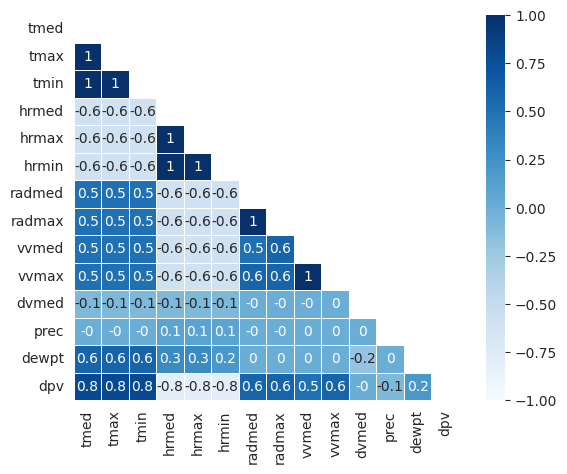

In [39]:
#Plot correlation between all features
corr=data_weather.corr()
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True
with sns.axes_style("white"):
    f, ax = plt.subplots(figsize=(7, 5))
    ax = sns.heatmap(corr.round(1), 
                     xticklabels=corr, yticklabels=corr,
                     mask=mask, vmin=-1, vmax=1, square=True,
                     annot = True, linewidths=.5, cmap="Blues")
#plt.savefig("Weather1.svg")

We see that there are groups of variables totally correlated. As a consequence, we select one of each group, so from *tmax*, *tmin* and *tmed* we pick *tmed*, from *hrmax*, *hrmin* and *hrmed* we pick *hrmed*, from *radmed* and *radmax* we pick *radmed* and from *vvmed* and *vvmax* we select *vvmed*.

Function to select the variables mentioned above, change the date format and resample all features computing the mean value:

In [40]:
def create_data_weather(datos, interval):
    weather = datos             
    #Select features
    weather = weather[['fecha' ,'hora', 'tmed', 'hrmed', 'radmed', 'vvmed', 'dvmed', 'prec', 'dewpt', 'dpv']]
    pd.options.mode.chained_assignment = None #To avoid false positive of SettingWithCopyWarning
    #Change date format
    weather['Date']= pd.to_datetime(weather.fecha+ ' '+weather.hora, format='%d/%m/%y %H:%M:%S')
    weather = weather.drop(columns=['fecha','hora'])
    weather['Date'] = pd.to_datetime(weather['Date'], utc = 'True')
    mask = (weather['Date'] >= '2021-01-01 00:00:00') & (weather['Date'] <= '2021-12-18 00:00:01')
    weather = weather.loc[mask]
    weather = weather.fillna(method="ffill")
    #Resample features
    weather = weather.resample(res_time, on='Date').mean().round(1)
    weather = weather.fillna(method="ffill")
    weather.to_csv(path + 'data-weather-' + interval + '.csv', sep=";")
    return weather

In [41]:
#Call function
res_time = '60T'
weather = create_data_weather(data_weather, res_time)

In [42]:
#Load data
weather = pd.read_csv('data/data-weather-' + res_time + '.csv', sep=";")
weather.head(3)

,Date,tmed,hrmed,radmed,vvmed,dvmed,prec,dewpt,dpv
0,2021-01-01 00:00:00+00:00,3.3,64.4,0.0,0.3,208.0,0.0,-2.7,0.3
1,2021-01-01 01:00:00+00:00,2.8,67.3,0.0,0.4,160.1,0.0,-2.7,0.2
2,2021-01-01 02:00:00+00:00,3.2,67.0,0.0,0.3,196.4,0.0,-2.4,0.3


### Dataset merge (consumption)

The last step consinst in merging all the DataFrames that we have created over this notebook. In order to do that we will perform consecutive merges with an inner join on *Fecha* (date). The result of this step will be a dataset ready to be used as input in a model designed to make consumption predictions.

In [43]:
def create_data_merge(cons, temp, hvac, weather, edificio, res_time):
    hvac = hvac[edificio]
    temp = temp[edificio]
    cons = cons[edificio]
    hvac['Date'] =  pd.to_datetime(hvac['Date'], utc = True)
    temp['Date'] =  pd.to_datetime(temp['Date'], utc = True)
    cons['Date'] = pd.to_datetime(cons['Date'], utc = True)
    cons.set_index('Date', inplace=True)
    weather['Date'] =  pd.to_datetime(weather['Date'], utc = True)
    
    df = pd.merge(cons, temp, left_on="Date", right_on="Date")
    df = pd.merge(df, hvac, left_on="Date", right_on="Date")
    df = pd.merge(df, weather, left_on="Date", right_on="Date")
    df = df.set_index('Date')
    mask = (df.index >= '2021-01-01 00:00:00') & (df.index <= '2021-12-18 00:00:01')
    df = df.loc[mask]
    df = df.reset_index()
    
    df.to_csv(path + 'data-model-consumo' + edificio + '-' + res_time + '.csv', sep=";")

In [44]:
#Call above results, so we dont need to run the whole notebook
res_time = '60T'
blocks = ['A','B','C']
cons = dict()
temp = dict()
hvac = dict()
for key in blocks: cons[key] = pd.read_csv(path + 'cons' + key +'-' + res_time + '.csv', sep=";")
for key in blocks: temp[key] = pd.read_csv(path + 'temp-sensor' + key +'-' + res_time + '.csv', sep=";")
for key in blocks: hvac[key] = pd.read_csv(path + 'hvac-agg' + key +'-' + res_time + '.csv', sep=";")
weather = pd.read_csv(path + 'data-weather-' + res_time + '.csv', sep=";")

In [45]:
#Call function
for block in blocks: create_data_merge(cons, temp, hvac, weather, block, res_time)

In [46]:
#Load data
dfs = dict()
for key in blocks: dfs[key] = pd.read_csv(path + 'data-model-consumo' + key +'-' + res_time + '.csv', sep=";", index_col=0)

In [47]:
dfs['A'].head(3)

,Date,dif_cons_real,cons_total,dif_cons_smooth,V2,V4,V12,V26,V5_0,V5_1,...,Season_3,Season_4,tmed,hrmed,radmed,vvmed,dvmed,prec,dewpt,dpv
0,2021-01-01 01:00:00+00:00,1.31,3.75,1.28,22.686829,1.0,14.1,0.0,0,1,...,0,0,2.8,67.3,0.0,0.4,160.1,0.0,-2.7,0.2
1,2021-01-01 02:00:00+00:00,1.30,5.05,1.29,22.642439,1.0,14.1,0.0,0,1,...,0,0,3.2,67.0,0.0,0.3,196.4,0.0,-2.4,0.3
2,2021-01-01 03:00:00+00:00,1.31,6.36,1.30,22.558780,1.0,14.1,0.0,0,1,...,0,0,3.5,67.8,0.0,0.2,190.8,0.0,-1.9,0.3


In [48]:
dfs['A'].info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8264 entries, 0 to 8263
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             8264 non-null   object 
 1   dif_cons_real    8264 non-null   float64
 2   cons_total       8264 non-null   float64
 3   dif_cons_smooth  8264 non-null   float64
 4   V2               8264 non-null   float64
 5   V4               8264 non-null   float64
 6   V12              8264 non-null   float64
 7   V26              8264 non-null   float64
 8   V5_0             8264 non-null   int64  
 9   V5_1             8264 non-null   int64  
 10  V5_2             8264 non-null   int64  
 11  Hour_1           8264 non-null   int64  
 12  Hour_2           8264 non-null   int64  
 13  Hour_3           8264 non-null   int64  
 14  Season_1         8264 non-null   int64  
 15  Season_2         8264 non-null   int64  
 16  Season_3         8264 non-null   int64  
 17  Season_4      

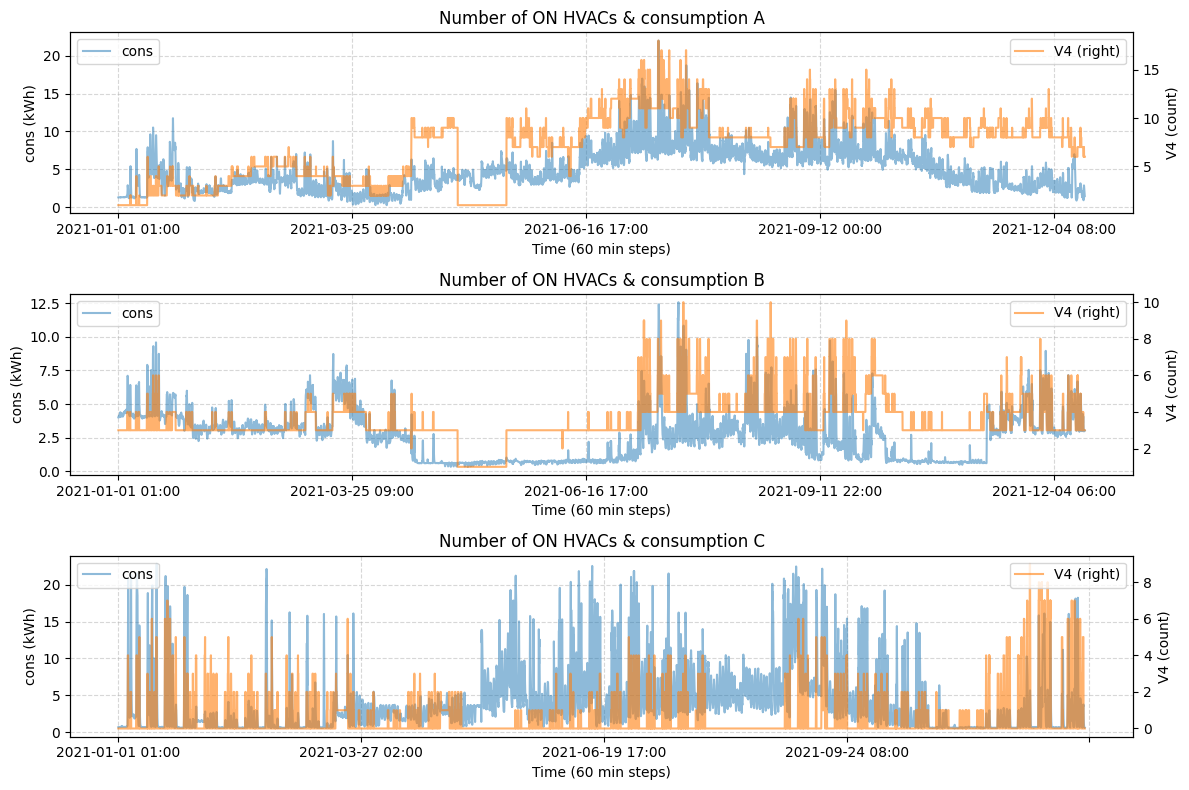

In [49]:
#Plot number of ON HVACs & consumption
fig, axs = plt.subplots(figsize=(12,8), nrows = 3, ncols =1, sharex =False)
for count, block in enumerate(['A','B','C']):
    axs[count].plot(pd.to_datetime(dfs[block]['Date']).dt.strftime("%Y-%m-%d %H:%M"),dfs[block]['dif_cons_smooth'], label='cons', alpha=0.5)
    ax = dfs[block]['V4'].plot(ax=axs[count], secondary_y=['V4'], use_index=False, alpha=0.6)
    ax.set_ylabel('V4 (count)')
    axs[count].set_xticks(np.arange(0, len(dfs['A']), 2000))
    plt.legend(loc = 'upper right')
    axs[count].grid(linestyle = "--", alpha=0.5)
    axs[count].legend(loc="upper left")
    axs[count].set_xlabel("Time (60 min steps)")
    axs[count].set_title("Number of ON HVACs & consumption " + block)
    axs[count].set_ylabel('cons (kWh)')
    axs[count].set_xlabel('Time (60 min steps)')
fig.tight_layout()
#plt.savefig("MergeCons1_date.svg")
plt.show()

Looking closely we can detect an strange behavior, for example around observation 3000 we see that the number of ON HVACs is always 1, but consumption is far from constant. Lets see the correlation between this:

In [50]:
df = pd.DataFrame({'block':['A','B','C'], 'res_time': res_time,
              'correlation': [dfs['A'][['dif_cons_smooth','V4']].corr().iloc[0,1],
                       dfs['B'][['dif_cons_smooth','V4']].corr().iloc[0,1], 
                       dfs['C'][['dif_cons_smooth','V4']].corr().iloc[0,1]]})
df

,block,res_time,correlation
0,A,60T,0.677337
1,B,60T,0.553585
2,C,60T,0.266004


Trying to solve that we do a smoothing on V4 in blocks A and C, and in block A we remove observations where the number of HVACs is smaller or equal to 1. While in B and C we do not do anything else. Selecting which observations to remove or not was a result of trial and error and looking for the higher correlation without removing too many observations. The new function to do this is:

In [51]:
def create_data_merge(cons, temp, hvac, weather, edificio, res_time):
    hvac = hvac[edificio]
    temp = temp[edificio]
    cons = cons[edificio]
    hvac['Date'] =  pd.to_datetime(hvac['Date'], utc = True)
    temp['Date'] =  pd.to_datetime(temp['Date'], utc = True)
    cons['Date'] = pd.to_datetime(cons['Date'], utc = True)
    cons.set_index('Date', inplace=True)
    weather['Date'] =  pd.to_datetime(weather['Date'], utc = True)
    
    df = pd.merge(cons, temp, left_on="Date", right_on="Date")
    df = pd.merge(df, hvac, left_on="Date", right_on="Date")
    df = pd.merge(df, weather, left_on="Date", right_on="Date")
    df = df.set_index('Date')
    #Remove observation
    if edificio == 'A': df = df.where(df['V4']>1).dropna()
    #Number of HVACs smoothing
    if edificio == 'A' or edificio == 'C':df['V4'] = df['V4'].ewm(span = 4).mean().round(0)
    
    mask = (df.index >= '2021-01-01 00:00:00') & (df.index <= '2021-12-18 00:00:01')
    df = df.loc[mask]
    df = df.reset_index()
    
    df.to_csv(path + 'data-model-consumo' + edificio + '-' + res_time + '.csv', sep=";")

In [52]:
#Call above results, so we dont need to run the whole notebook
res_time = '60T'
blocks = ['A','B','C']
cons = dict()
temp = dict()
hvac = dict()
for key in blocks: cons[key] = pd.read_csv(path + 'cons' + key +'-' + res_time + '.csv', sep=";")
for key in blocks: temp[key] = pd.read_csv(path + 'temp-sensor' + key +'-' + res_time + '.csv', sep=";")
for key in blocks: hvac[key] = pd.read_csv(path + 'hvac-agg' + key +'-' + res_time + '.csv', sep=";")
weather = pd.read_csv(path + 'data-weather-' + res_time + '.csv', sep=";")

In [53]:
#Call function
for block in blocks: create_data_merge(cons, temp, hvac, weather, block, res_time)

In [54]:
#Load data
dfs = dict()
for key in blocks: dfs[key] = pd.read_csv(path + 'data-model-consumo' + key +'-' + res_time + '.csv', sep=";", index_col=0)

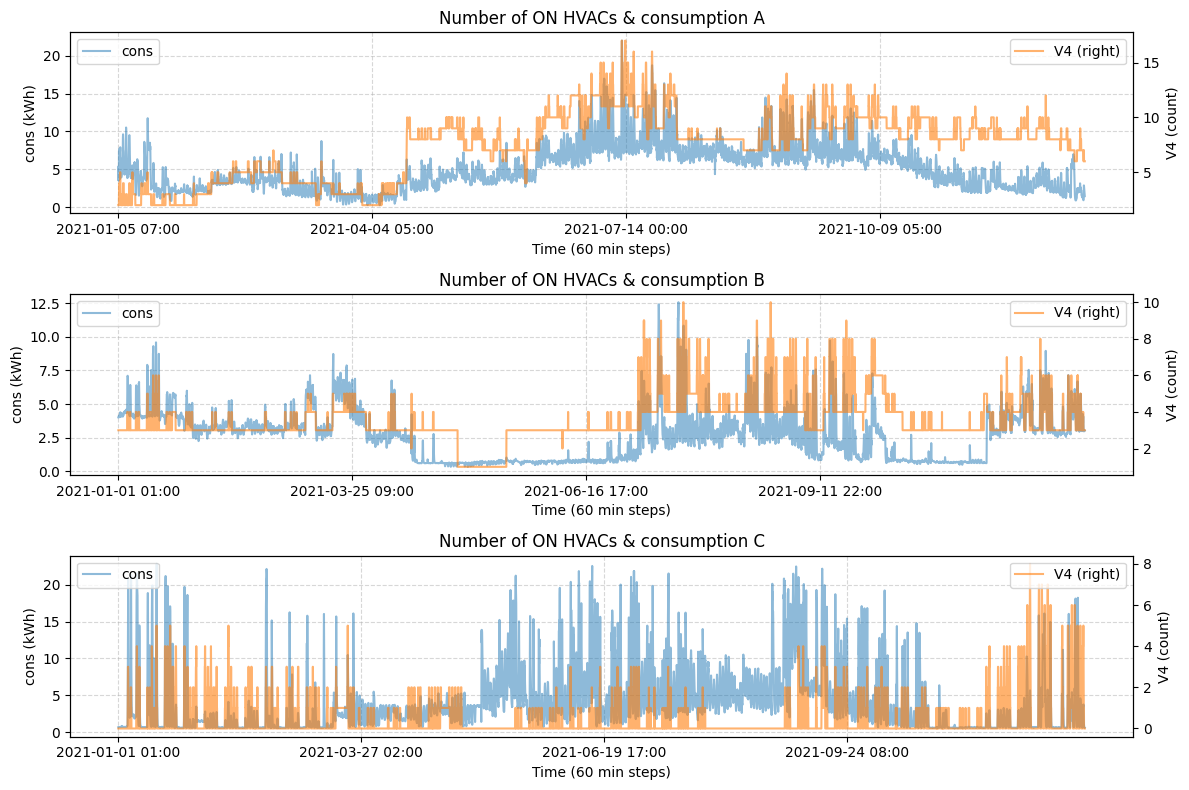

In [55]:
#Plot number of ON HVACs & consumption
fig, axs = plt.subplots(figsize=(12,8), nrows = 3, ncols =1, sharex =False)
for count, block in enumerate(['A','B','C']):
    axs[count].plot(pd.to_datetime(dfs[block]['Date']).dt.strftime("%Y-%m-%d %H:%M"),dfs[block]['dif_cons_smooth'], label='cons', alpha=0.5)
    ax = dfs[block]['V4'].plot(ax=axs[count], secondary_y=['V4'], use_index=False, alpha=0.6)
    ax.set_ylabel('V4 (count)')
    plt.legend(loc = 'upper right')
    axs[count].set_xticks(np.arange(0, len(dfs['A']), 2000))
    axs[count].grid(linestyle = "--", alpha=0.5)
    axs[count].legend(loc="upper left")
    axs[count].set_xlabel("Time (60 min steps)")
    axs[count].set_title("Number of ON HVACs & consumption " + block)
    axs[count].set_ylabel('cons (kWh)')
    axs[count].set_xlabel('Time (60 min steps)')
fig.tight_layout()
#plt.savefig("MergeCons2_date.svg")
plt.show()

In [56]:
df = pd.DataFrame({'block':['A','B','C'], 'res_time': res_time,
              'correlation': [dfs['A'][['dif_cons_smooth','V4']].corr().iloc[0,1],
                       dfs['B'][['dif_cons_smooth','V4']].corr().iloc[0,1], 
                       dfs['C'][['dif_cons_smooth','V4']].corr().iloc[0,1]]})
df

,block,res_time,correlation
0,A,60T,0.713264
1,B,60T,0.553585
2,C,60T,0.313860


In this way, we have the optimal data to use for predictions.

### Dataset merge (temperature)

To make temperature predictions a lower level of granularity is needed. This is a room level granularity and to achieve that we will use again the relationships between devices, HVACs and sensors. Also, in this case the resample time will be 10 minutes, not 60. Therefore, a step by step procedure will be done, divided in two parts.

*Note: files created in this section weight ~250mb each* 

In [57]:
def create_data_room_part1(block, cons, weather, relations_sensor, relations_hvac, data_hvac, data_temp, interval):
    #cons, weather                                          #Processed
    #relations_sensor, relations_hvac, data_hvac, data_temp #Raw
    
    #Select observations from a given block from HVAC data
    data = data_hvac
    mask = data['IDdevice'].isin(ids_hvac[block])
    df = data.loc[mask]
    #Remove extreme values
    df = df.sort_values(by=['IDdevice', 'Date'], ascending=True)
    mask = (data['V12']<=0) | (data['V12']>60)
    data.loc[mask, 'V12'] = np.nan
    df['V12'] = df['V12'].fillna(method="ffill")
    mask = (df['V4']==0)
    df.loc[mask, 'V26'] = 0
    df = df[["IDdevice", "Date", "V4", "V5", "V12", "V26"]]
    #Merge to have every instance with its block and room
    df1 = pd.merge(df, relations_hvac, left_on="IDdevice", right_on="ID")
    df1 = df1[["Date","IDdevice", "block", "room","V4", "V5", "V12", "V26"]]
    df1 = df1.set_index(['Date'])
    df1.index = pd.to_datetime(df1.index, utc = True)
    #Group observations by device, block and room
    df1_1 = df1.groupby(['IDdevice','block', 'room']).resample(interval)['V12'].mean().to_frame().reset_index()
    df1_1['V12'] = df1_1['V12'].fillna(method="ffill")
    df1_2 = df1.groupby(['IDdevice','block', 'room']).resample(interval)['V5'].median().to_frame().reset_index()
    df1_2['V5'] = df1_2['V5'].fillna(method="ffill")
    df1_3 = df1.groupby(['IDdevice','block', 'room']).resample(interval)['V4'].mean().round().to_frame().reset_index()
    df1_3['V4'] = df1_3['V4'].fillna(method="ffill")
    df1_4 = df1.groupby(['IDdevice','block', 'room']).resample(interval)['V26'].mean().round(1).to_frame().reset_index()
    df1_4['V26'] = df1_4['V26'].fillna(method="ffill")
    df1 = pd.merge(df1_1,df1_2)
    df1 = pd.merge(df1,df1_3)
    df1 = pd.merge(df1,df1_4)
    df1['V5'] = df1['V5'].astype(int)
    mask = (df1['V4']==0)
    df1.loc[mask, 'V5'] = 0
    df1 = pd.concat([df1, pd.get_dummies(df1.V5, prefix='V5')], axis=1).drop(columns=['V5'])
    df1 = df1.rename(columns={'IDdevice': 'IDhvac'})
    try :df1.drop(columns=['V5_3', 'V5_4'], inplace = True)
    except Exception: pass
    #Now we repeat the process with temperature
    data = data_temp
    mask = data['IDdevice'].isin(ids_sensor[block])
    df = data.loc[mask]
    df = df[["IDdevice", "Date", "V2"]]
    df2 = pd.merge(df, relations_sensor, left_on="IDdevice", right_on="ID")
    df2 = df2.set_index('Date')
    df2.index = pd.to_datetime(df2.index, utc = True)
    df2 = df2[["IDdevice", "V2", "block", "room"]]
    df2 = df2.sort_values(by=['IDdevice'], ascending=True)
    mask = (df2['V2']<15) | (df2['V2']>40)
    df2.loc[mask, 'V2'] = np.nan
    df2['V2'] = df2['V2'].fillna(method="ffill")
    df2 = df2.sort_values(by=['Date'], ascending=False)
    df2 = df2.groupby(['IDdevice','block', 'room']).resample(interval)['V2'].mean().to_frame()
    df2['V2'] = df2['V2'].fillna(method="ffill")
    df2 = df2.reset_index()
    df2 = df2.rename(columns={'IDdevice': 'IDsensor'})
    #Add consumption data (for completeness, it wont be necessary for temperature predictions)
    data = cons[block]
    data['Date'] =  pd.to_datetime(data['Date'], utc = True)
    weather['Date'] =  pd.to_datetime(weather['Date'], utc = True)
    merge1 = pd.merge(data, df1, how="inner")
    merge2 = pd.merge(merge1, df2, how="inner", on = ["Date",'block','room'])
    merge2['Date'] =  pd.to_datetime(merge2['Date'], utc = True)
    merge3 = pd.merge(merge2, weather, how="inner")
    merge3 = merge3.round({'dif_cons': 2,'cons_total': 2, 'V2': 1})
    #Add hour feature
    merge3['Date'] =  pd.to_datetime(merge3['Date'], utc = True)
    def Hour_(Hour):
        if Hour in range(6,14): return 1
        if Hour in range(14,22): return 2
        if Hour in [22,23,0,1,2,3,4,5]: return 3
    merge3['Hour'] = merge3['Date'].dt.hour
    merge3['Hour'] = merge3['Hour'].apply(Hour_).astype(int)
    merge3 = pd.concat([merge3, pd.get_dummies(merge3.Hour, prefix='Hour')], axis=1).drop(columns=['Hour'])
    #Add season
    def season(Mes):
        if Mes in range(1,4): return 1
        if Mes in range(4,7): return 2
        if Mes in range(7,10): return 3
        if Mes in range(10,13): return 4
    merge3['Season'] = merge3['Date'].dt.month
    merge3['Season'] = merge3['Season'].apply(season).astype(int)
    merge3 = pd.concat([merge3, pd.get_dummies(merge3.Season, prefix='Season')], axis=1).drop(columns=['Season'])
    merge3.to_csv(path + 'data-room' + block + '-' + interval + '.csv', sep=";", index=False)

In [58]:
blocks = ['A','B','C']
res_time = '10T'
ids_sensor = dict()
ids_hvac = dict()
rooms_sensor = dict()
rooms_hvac = dict()
cons = dict()
for key in blocks: cons[key] = pd.read_csv(path + 'cons' + key +'-' + res_time + '.csv', sep=";")
weather = pd.read_csv(path + 'data-weather-' + res_time + '.csv', sep=";")
for key in blocks:
    ids_sensor[key] = relations_sensor['ID'].where(relations_sensor['block']== key).dropna().unique().astype(int).tolist()
    ids_hvac[key] = relations_hvac['ID'].where(relations_hvac['block']== key).dropna().unique().astype(int).tolist()
    rooms_sensor[key] = relations_sensor['room'].where(relations_sensor['block']== key).dropna().unique().tolist()
    rooms_hvac[key] = relations_hvac['room'].where(relations_hvac['block']== key).dropna().unique().tolist()

In [59]:
#Call the function
for block in blocks: create_data_room_part1(block, cons, weather, relations_sensor, relations_hvac, data_hvac, data_temp, res_time)

In [60]:
#Load data into a dictionary
merge = dict()
for key in blocks:
    merge[key] = pd.read_csv(path + 'data-room' + key +'-' + res_time + '.csv', sep=";")

In [61]:
def create_data_room_part2(merge, rooms_hvac, rooms_sensor, res_time):
    df = pd.concat([merge['A'],merge['B'],merge['C']]).sort_values(by=['block','Date'], ascending=[True, False])
    df = df.astype({'IDhvac': 'string', 'IDsensor': 'string'})
    df = df.groupby(['Date', 'room', 'block']).mean().reset_index()
    df = df.astype({'Date': 'string'})
    #Look for the rooms that we have both temperature sensor and HVAC
    rooms_A = list(set(rooms_hvac['A']).intersection(rooms_sensor['A']))
    rooms_B = list(set(rooms_hvac['B']).intersection(rooms_sensor['B']))
    rooms_C = list(set(rooms_hvac['C']).intersection(rooms_sensor['C']))
    rooms = rooms_A + rooms_B + rooms_C
    
    dti = pd.date_range(start="2021-01-01 00:10:00", end="2021-12-17 23:50:00", freq="10T")
    dti = dti.tz_localize("UTC")
    df_time = pd.DataFrame()
    df_time['Date'] = np.repeat(dti.astype(str),len(rooms))
    rooms = rooms
    df_time['room'] = rooms*len(dti)
    df_time['block'] = (list(np.repeat('A',len(rooms_A))) + list(np.repeat('B',len(rooms_B))) + list(np.repeat('C',len(rooms_C))))*len(dti)
    
    merge_final = pd.merge(df_time, df, how = 'left', on=['Date','room', 'block']).round({'dif_cons': 2,'cons_total': 2, 'V2': 1, 'V4':0})
    try :merge_final.dropna(axis=1, inplace = True)
    except Exception: pass
    merge_final.to_csv(path + 'data-room' + res_time + '-all.csv', sep=";", index = False)

In [62]:
create_data_room_part2(merge, rooms_hvac, rooms_sensor, res_time)

/tmp/ipykernel_17157/2849938293.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df = df.groupby(['Date', 'room', 'block']).mean().reset_index()


In [64]:
merge_final = pd.read_csv(path + 'data-room' + res_time + '-all.csv', sep=";")

In [65]:
merge_final

,Date,room,block,dif_cons,cons_total,V12,V4,V26,V5_0,V5_1,...,prec,dewpt,dpv,Hour_1,Hour_2,Hour_3,Season_1,Season_2,Season_3,Season_4
0,2021-01-01 00:10:00+00:00,34.0,A,0.23,1.55,21.0,0.0,0.0,1.0,0.0,...,0.0,-2.3,0.3,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1,2021-01-01 00:10:00+00:00,35.0,A,0.23,1.55,21.0,0.0,0.0,1.0,0.0,...,0.0,-2.3,0.3,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2,2021-01-01 00:10:00+00:00,36.0,A,0.23,1.55,24.0,0.0,0.0,1.0,0.0,...,0.0,-2.3,0.3,0.0,0.0,1.0,1.0,0.0,0.0,0.0
3,2021-01-01 00:10:00+00:00,37.0,A,0.23,1.55,24.0,0.0,0.0,1.0,0.0,...,0.0,-2.3,0.3,0.0,0.0,1.0,1.0,0.0,0.0,0.0
4,2021-01-01 00:10:00+00:00,38.0,A,0.23,1.55,24.0,0.0,0.0,1.0,0.0,...,0.0,-2.3,0.3,0.0,0.0,1.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2527145,2021-12-17 23:50:00+00:00,17.0,B,0.52,22403.96,27.0,0.0,0.0,1.0,0.0,...,0.0,8.0,0.3,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2527146,2021-12-17 23:50:00+00:00,18.0,B,0.52,22403.96,25.0,0.0,0.0,1.0,0.0,...,0.0,8.0,0.3,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2527147,2021-12-17 23:50:00+00:00,32.0,C,0.09,41624.85,23.0,0.0,0.0,1.0,0.0,...,0.0,8.0,0.3,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2527148,2021-12-17 23:50:00+00:00,29.0,C,0.09,41624.85,23.5,0.0,0.0,1.0,0.0,...,0.0,8.0,0.3,0.0,0.0,1.0,0.0,0.0,0.0,1.0


This dataset can be used, for example, to train a model for indoor temperature forecast or to predict the setpoints set by the users, among many possible applications.

### Presence and CO2 (data-presence and data-co2)

Lastly, we have acquired data regarding CO2 concentration (in parts per million, ppm) and presence in a few rooms belonging to blocks A and B.

The CO2 data only has three features:
- **IDdevice**: device identifier.
- **Date**: timestamp with format %Y-%m-%d %H:%M:%S.
- **V17**: current value of CO2 (ppm).

In [3]:
data_co2.head(3)

,IDdevice,Date,V17
0,335547772,2021-01-01 00:00:11.342+01,319.039703
1,335547903,2021-01-01 00:00:11.342+01,18.853523
2,335547804,2021-01-01 00:00:19.394+01,-24.033585


One thing to consider about this dataset is that not all the devices measure CO2. Out off all the IDs (35 in total, can be seen with *data_co2['IDdevice'].unique()*), only 12 are for CO2 measurements (335544753, 335544767, 335544803, 335544804, 335544828, 335545016, 335544849, 335544850, 335544688, 335544705, 335544712, 335544713) so the remaning instances should not be used and remove to make the file lighter.

Then, for presence we have again three features again:
- **IDdevice**: device identifier.
- **Date**: timestamp with format %Y-%m-%d %H:%M:%S.
- **V2**: Presence with values 0 or 1 (will be renamed as *Presence* so there is no confussion with temperature *V2*).

One important aspect to keep into account is that the presence value is retrieved from a motion sensor which turns on when someone moves and then turns off after a certain time, usually between a few seconds and three minutes. Therefore, this data should not be considered as occupancy but as a reference to infer it later. One approach could be considering observations that have a 1 near zeros in a interval lower than ~3 minutes as continuous presence. In this way, only the zeros that are far from ones would be considered as not presence and we would ignore the zeros that appear when the sensor is turned off but someone is actually in the room yet.

In [4]:
data_presence.head(3)

,IDdevice,Date,V2
0,335545054,2021-12-31 19:39:03.23+01,0
1,335545054,2021-12-31 19:36:30.859+01,1
2,335545054,2021-12-31 17:51:51.64+01,0


The relations of devices IDs with their respective rooms and blocks are provided by *relations_co2* and *relations_presence*:

In [5]:
relations_co2.head(3)

,block,room,ID
0,A,37,335547753
1,A,38,335547772
2,A,42,335547792


In [6]:
relations_presence.head(3)

,block,room,ID
0,A,37,335544753
1,A,38,335544767
2,A,42,335544803


Merge the CO2 data with relations so we only have the historical data of the devies we are interested in

In [7]:
df_co2 = pd.merge(data_co2, relations_co2, left_on="IDdevice", right_on="ID")

In [8]:
df_co2.head(3)

,IDdevice,Date,V17,block,room,ID
0,335547772,2021-01-01 00:00:11.342+01,319.039703,A,38,335547772
1,335547772,2021-01-01 00:02:12.056+01,313.045715,A,38,335547772
2,335547772,2021-01-01 00:04:12.582+01,319.774841,A,38,335547772


In [9]:
df_co2 = pd.merge(data_co2, relations_co2, left_on="IDdevice", right_on="ID")
df_co2 = df_co2[['Date','V17','block','room','IDdevice']]
#Group observations by device, block and room and resample CO2 in 10 minute intervals
interval = '10T'
df_co2 = df_co2.set_index(['Date'])
df_co2.index = pd.to_datetime(df_co2.index, utc = True)
df_co2 = df_co2.groupby(['IDdevice','block', 'room']).resample(interval)['V17'].mean().to_frame().reset_index()

And replicate the process with presence:

In [10]:
df_presence = pd.merge(data_presence, relations_presence, left_on="IDdevice", right_on="ID")
df_presence = df_presence[['Date','V2','block','room','IDdevice']].rename(columns={"V2": "Presence"})
interval = '10T'
df_presence = df_presence.set_index(['Date'])
df_presence.index = pd.to_datetime(df_presence.index, utc = True)
#Group observations by device, block and room
df_presence = df_presence.groupby(['IDdevice','block', 'room']).resample(interval)['Presence'].max().to_frame().fillna(0).reset_index()
#If it returns NaN it is because there is no register in that timestep, and therefore the room is empty
#Therefore, those NaN values are overwriten with zeros

Finally, we merge presence and CO2 data with the idea of being able to relate occupancy with CO2 levels, but the application of this dataset is left open for the reader. Next we try to see if actually, those two features behave alike.

In [11]:
merge = pd.merge(df_co2, df_presence, how="inner", on = ["Date",'block','room']).drop(columns=['IDdevice_x','IDdevice_y'])

In [12]:
merge.head(3)

,block,room,Date,V17,Presence
0,A,37,2021-01-11 12:00:00+00:00,100.710703,1.0
1,A,37,2021-01-11 12:10:00+00:00,100.574988,0.0
2,A,37,2021-01-11 12:20:00+00:00,105.980908,0.0


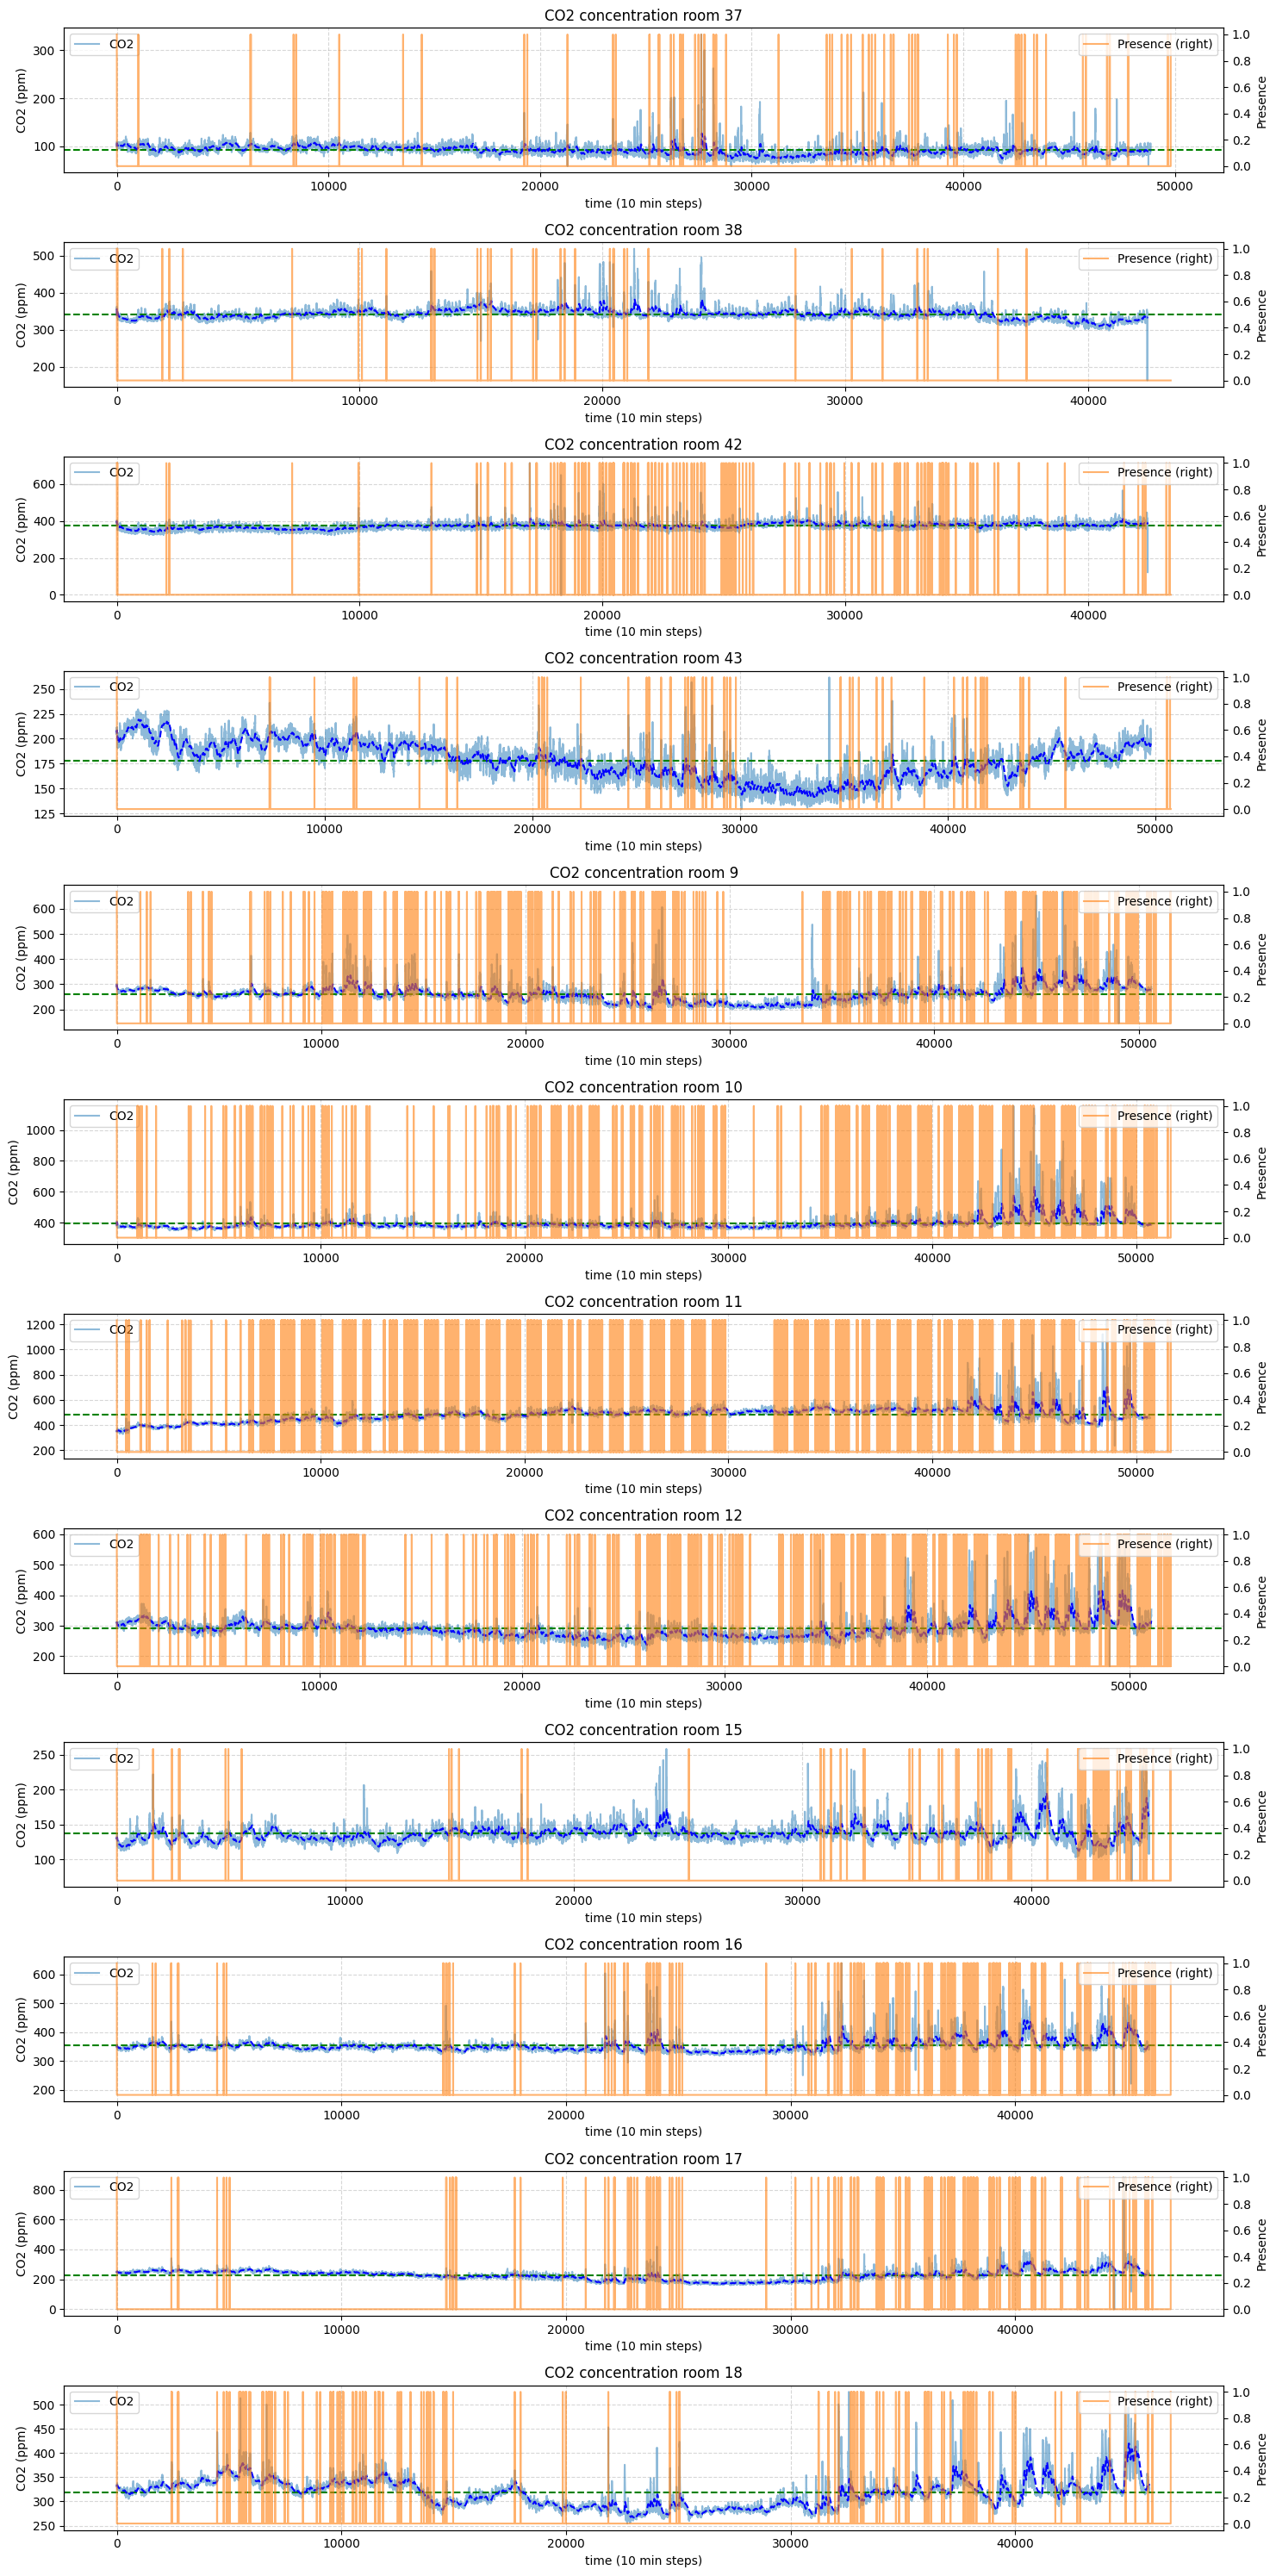

In [13]:
fig, axs = plt.subplots(figsize=(15,30), nrows = 12, ncols =1, sharex =False)
for count, room in enumerate(merge['room'].unique()):
    mask = (merge['room']==room)
    axs[count].plot(merge.loc[mask,'V17'].dropna().reset_index(drop=True), label='CO2', alpha=0.5)
    ax = merge.loc[mask,'Presence'].dropna().reset_index(drop=True).plot(ax=axs[count], secondary_y=['Presence'], use_index=False, alpha=0.6)
    #axs[count].axhline(y=400, color='r', linestyle='--')
    axs[count].axhline(y=merge.loc[mask,'V17'].dropna().mean(), color='g', linestyle='--')
    axs[count].plot(merge.loc[mask,'V17'].dropna().reset_index(drop=True).ewm(span=24*7).mean(), color='b', linestyle='--')
    axs[count].set_title("CO2 concentration room " + str(room))
    axs[count].set_ylabel('CO2 (ppm)')
    axs[count].set_xlabel('time (10 min steps)')
    ax.set_ylabel('Presence')
    plt.legend(loc = 'upper right')
    axs[count].grid(linestyle = "--", alpha=0.5)
    axs[count].legend(loc="upper left")
fig.tight_layout()

In [ ]:
fig, axs = plt.subplots(figsize=(15,30), nrows = 12, ncols =1, sharex =False)
for count, room in enumerate(merge['room'].unique()):
    mask = (merge['room']==room)
    #axs[count].plot(merge.loc[mask,'V17'].dropna().reset_index(drop=True), label='CO2', alpha=0.5)
    axs[count].plot(pd.to_datetime(merge.loc[mask].dropna()['Date']).dt.strftime("%Y-%m-%d %H:%M"),merge.loc[mask,'V17'].dropna(), label='CO2', alpha=0.5)
    ax = merge.loc[mask,'Presence'].dropna().reset_index(drop=True).plot(ax=axs[count], secondary_y=['Presence'], use_index=False, alpha=0.6)
    ax.set_ylabel('Presence')
    axs[count].axhline(y=merge.loc[mask,'V17'].dropna().mean(), color='g', linestyle='--')
    axs[count].plot(merge.loc[mask,'V17'].dropna().reset_index(drop=True).ewm(span=24*7).mean(), color='b', linestyle='--')
    axs[count].set_title("CO2 concentration room " + str(room))
    axs[count].set_ylabel('CO2 (ppm)')
    axs[count].set_xlabel('time (10 min steps)')
    axs[count].set_xticks(np.arange(0, len(merge), 12000))
    axs[count].grid(linestyle = "--", alpha=0.5)
    axs[count].legend(loc="upper left")
    plt.legend(loc = 'upper right')
fig.tight_layout()


#     axs[count].plot(pd.to_datetime(dfs[block]['Date']).dt.strftime("%Y-%m-%d %H:%M"),dfs[block]['dif_cons_smooth'], label='cons', alpha=0.5)
#     ax = dfs[block]['V4'].plot(ax=axs[count], secondary_y=['V4'], use_index=False, alpha=0.6)
#     ax.set_ylabel('V4 (count)')
#     plt.legend(loc = 'upper right')
#     axs[count].set_xticks(np.arange(0, len(dfs['A']), 2000))
#     axs[count].grid(linestyle = "--", alpha=0.5)
#     axs[count].legend(loc="upper left")
#     axs[count].set_xlabel("Time (60 min steps)")
#     axs[count].set_title("Number of ON HVACs & consumption " + block)
#     axs[count].set_ylabel('cons (kWh)')
#     axs[count].set_xlabel('Time (60 min steps)')

Here, the dashed green line representes the mean value of CO2 over the year, and the blue one is CO2 smoothed with a 7-day window.

We can appreciate that the CO2 levels differ considerably from one room to another. To put this into perpective, average CO2 concentration is ~400ppm. And over that base, air quality levels are established:
- Optimal: 400-600 ppm
- Good: 600-800 ppm
- Medium: 800-1000 ppm
- Bad: >1000 ppm

In [14]:
#Python version
import platform
print(platform.python_version())

3.8.3
